<a href="https://colab.research.google.com/github/OhmPandya/Potato-Capstone-ML-/blob/main/ML_model_SykitLearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Import DataSet**

In [48]:
from google.colab import files

uploaded = files.upload()

Saving T_500_seconds.csv to T_500_seconds (1).csv


In [49]:
import pandas as pd
import io

# Assuming you uploaded a single CSV file named 'Capstone.csv'
# If the file has a different name, please update 'Capstone.csv' below.
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(io.BytesIO(uploaded[fn]))

df

User uploaded file "T_500_seconds (1).csv" with length 10315 bytes


,Time_seconds,Internal Temperature,External Temperature,Relay Switch
0,0.0,23.00,27.75,1
1,2.0,23.25,27.50,1
2,4.0,23.00,28.00,1
3,6.0,22.75,27.25,1
4,8.0,22.75,27.75,1
...,...,...,...,...
522,1043.7,105.75,119.25,0
523,1045.7,105.75,119.75,0
524,1047.7,105.25,120.00,0
525,1049.7,105.50,120.00,0


#### **Data Preparation**

In [50]:
X = df.drop(['Internal Temperature', 'Relay Switch'], axis=1)
y = df.drop(['External Temperature', 'Time_seconds'], axis=1)
X

,Time_seconds,External Temperature
0,0.0,27.75
1,2.0,27.50
2,4.0,28.00
3,6.0,27.25
4,8.0,27.75
...,...,...
522,1043.7,119.25
523,1045.7,119.75
524,1047.7,120.00
525,1049.7,120.00


#### **Data Splitting**

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)


# **Model Building**

### **Linear Regression**

Training Model

In [52]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train[['External Temperature']], y_train)

LinearRegression()

Applying the model to make Prediction

In [54]:
y_lr_train_pred = lr.predict(X_train[['External Temperature']])
y_lr_test_pred = lr.predict(X_test[['External Temperature']])

print(y_lr_train_pred)

[[ 90.53992266   0.8603377 ]
 [ 69.327898     0.92189867]
 [ 71.952066     0.91428288]
 [ 19.68738667   1.06596403]
 [ 22.31155467   1.05834824]
 [ 30.18405867   1.03550087]
 [ 52.270806     0.97140131]
 [ 19.68738667   1.06596403]
 [ 99.28714933   0.83495174]
 [ 56.64441933   0.95870832]
 [ 44.83566334   0.99297938]
 [ 99.06846866   0.83558639]
 [ 31.933504     1.03042368]
 [ 95.35089733   0.84637542]
 [ 19.25002534   1.06723333]
 [ 96.00693933   0.84447148]
 [ 83.97950266   0.87937718]
 [ 92.72672933   0.85399121]
 [ 92.94540999   0.85335656]
 [ 97.75638466   0.83939428]
 [ 51.17740267   0.97457455]
 [ 40.46205      1.00567236]
 [ 60.36199067   0.94791929]
 [ 94.91353599   0.84764472]
 [ 99.94319133   0.83304779]
 [ 65.17296533   0.93395701]
 [ 88.35311599   0.8666842 ]
 [ 98.19374599   0.83812498]
 [ 21.87419334   1.05961754]
 [100.38055266   0.83177849]
 [ 42.64885667   0.99932587]
 [ 54.45761267   0.96505481]
 [ 22.53023534   1.05771359]
 [ 67.14109133   0.92824516]
 [ 88.35311599

In [55]:
print(y_lr_test_pred)

[[ 91.63332599   0.85716446]
 [ 97.53770399   0.84002893]
 [ 93.82013266   0.85081797]
 [ 89.88388066   0.86224165]
 [ 92.72672933   0.85399121]
 [ 90.97728399   0.85906841]
 [ 98.63110733   0.83685569]
 [ 52.70816733   0.97013201]
 [ 97.10034266   0.84129823]
 [ 97.10034266   0.84129823]
 [ 61.89275533   0.94347674]
 [ 29.52801667   1.03740482]
 [ 21.43683201   1.06088684]
 [ 92.72672933   0.85399121]
 [ 40.02468867   1.00694166]
 [ 59.487268     0.95045788]
 [ 21.87419334   1.05961754]
 [ 96.66298133   0.84256753]
 [ 95.78825866   0.84510612]
 [ 48.990596     0.98092104]
 [ 21.65551267   1.06025219]
 [ 30.84010067   1.03359692]
 [ 60.14331      0.94855394]
 [ 29.309336     1.03803947]
 [ 35.869756     1.01899999]
 [ 78.07512466   0.89651271]
 [ 91.63332599   0.85716446]
 [ 25.373084     1.04946315]
 [ 58.39386467   0.95363113]
 [ 88.79047733   0.8654149 ]
 [ 96.66298133   0.84256753]
 [ 19.46870601   1.06659868]
 [ 97.10034266   0.84129823]
 [ 95.13221666   0.84701007]
 [ 69.54657866

**Evaluate Model Performance**

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [57]:
print('LR MSE (Train): ', lr_train_mse)
print('LR R2 (Train): ', lr_train_r2)
print('LR MSE (Test): ', lr_test_mse)
print('LR R2 (Test): ', lr_test_r2)



LR MSE (Train):  6.324376816595694
LR R2 (Train):  0.5474171471775566
LR MSE (Test):  6.377865166103191
LR R2 (Test):  0.43046210507816957


In [58]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']
lr_results
#

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,6.324377,0.547417,6.377865,0.430462


### **Random Forest**

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

#### Applying Model to make Prediction

In [60]:
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

#### **Evaluate Model Performance**

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random Forest,14.221202,0.578977,13.34839,0.312847


## **Model Comparison**

In [62]:
df_models = pd.concat([lr_results, rf_results], axis=0)
df_models.reset_index(drop=True)

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,6.324377,0.547417,6.377865,0.430462
1,Random Forest,14.221202,0.578977,13.34839,0.312847


# **Data Visualization for Predection results**

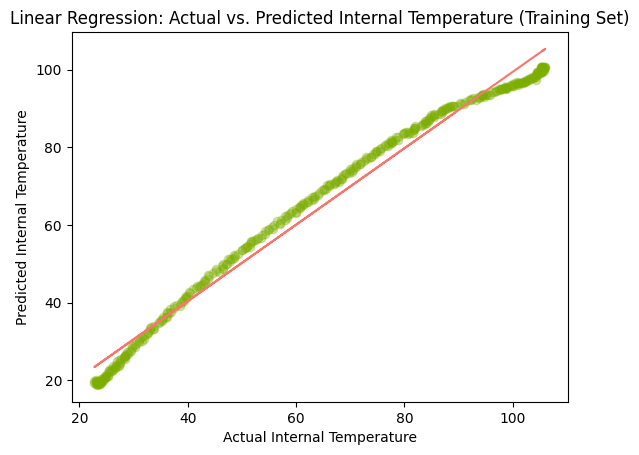

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'Internal Temperature' is the first column in y_train and y_lr_train_pred
plt.scatter(x=y_train['Internal Temperature'], y=y_lr_train_pred[:, 0], c="#7CAE00", alpha=0.3)

z=np.polyfit(y_train['Internal Temperature'], y_lr_train_pred[:, 0], 1)
p=np.poly1d(z)
plt.plot(y_train['Internal Temperature'], p(y_train['Internal Temperature']), c='#F8766D')
plt.xlabel("Actual Internal Temperature")
plt.ylabel("Predicted Internal Temperature")
plt.title("Linear Regression: Actual vs. Predicted Internal Temperature (Training Set)")
plt.show()